In [1]:
import pandas as pd

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [8]:
import numpy as np

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
import json

In [28]:
from ydata_profiling import ProfileReport

c:\Users\Tejas\anaconda3\envs\myRAG\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_Data = pd.read_csv('NOC_Competencies.csv')

In [5]:
df_Data.columns.tolist()

['OaSIS 2021 Codes',
 'OaSIS 2021 Labels',
 'Active Listening',
 'Digital Literacy',
 'Numeracy',
 'Oral Comprehension',
 'Oral Expression',
 'Reading Comprehension',
 'Writing',
 'Decision Making',
 'Evaluation',
 'Learning and Teaching Strategies',
 'Problem Solving',
 'Systems Analysis',
 'Critical Thinking',
 'Digital Production',
 'Equipment and Tool Selection',
 'Operation and Control',
 'Operation Monitoring of Machinery and Equipment',
 'Preventative Maintenance',
 'Product Design',
 'Quality Control Testing',
 'Repairing',
 'Setting Up',
 'Troubleshooting',
 'Management of Financial Resources',
 'Management of Material Resources',
 'Management of Personnel Resources',
 'Monitoring',
 'Time Management',
 'Coordinating',
 'Instructing',
 'Negotiating',
 'Persuading',
 'Social Perceptiveness']

In [6]:
Features = ['Active Listening',
 'Digital Literacy',
 'Numeracy',
 'Oral Comprehension',
 'Oral Expression',
 'Reading Comprehension',
 'Writing',
 'Decision Making',
 'Evaluation',
 'Learning and Teaching Strategies',
 'Problem Solving',
 'Systems Analysis',
 'Critical Thinking',
 'Digital Production',
 'Equipment and Tool Selection',
 'Operation and Control',
 'Operation Monitoring of Machinery and Equipment',
 'Preventative Maintenance',
 'Product Design',
 'Quality Control Testing',
 'Repairing',
 'Setting Up',
 'Troubleshooting',
 'Management of Financial Resources',
 'Management of Material Resources',
 'Management of Personnel Resources',
 'Monitoring',
 'Time Management',
 'Coordinating',
 'Instructing',
 'Negotiating',
 'Persuading',
 'Social Perceptiveness']

print(f"Number of Features: {len(Features)}")

Number of Features: 33


In [ ]:
#There are 33 Features, we need to reduce them down to 8 to 10 for the entry form. 
#Steps:
#1. Determine the features that carry the most variance through PCA.
#2. Find the top 15 Features.
#3. Elimate reduncies by finding high correlations between 15 features and removing the least important feature.

1. PCA

In [ ]:
#Standardizing the features -- Not really necessary since all metrics are scaled the same, but still a good practice.
X = df_Data[Features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
pca = PCA(n_components=15)
pca.fit(X_scaled)

,n_components,15
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [12]:
pca.components_.shape

(15, 33)

In [13]:
#Getting the absolute magnitude of importance per PCA and calculating the mean.

importance = (
    np.abs(pca.components_) *
    pca.explained_variance_ratio_[:, None]
).sum(axis=0)

#Merging importance back per feature.
feature_importance = pd.Series(
    importance,
    index=Features
).sort_values(ascending=False)

2. Determine top 15 Feature based on PCA

In [ ]:
feature_importance.head(15) #Top 15 Feature that explain the most variance according to the PCA.

Numeracy                             0.156499
Social Perceptiveness                0.151637
Negotiating                          0.150493
Management of Financial Resources    0.148936
Digital Literacy                     0.148510
Systems Analysis                     0.147100
Management of Material Resources     0.146632
Persuading                           0.146397
Evaluation                           0.145473
Writing                              0.142817
Instructing                          0.142690
Management of Personnel Resources    0.142360
Active Listening                     0.142188
Oral Expression                      0.141842
Reading Comprehension                0.141542
dtype: float64

3. Elimnate Redundancies 

In [17]:
Features_For_Correlation = list(feature_importance.head(15).index)
Features_For_Correlation

['Numeracy',
 'Social Perceptiveness',
 'Negotiating',
 'Management of Financial Resources',
 'Digital Literacy',
 'Systems Analysis',
 'Management of Material Resources',
 'Persuading',
 'Evaluation',
 'Writing',
 'Instructing',
 'Management of Personnel Resources',
 'Active Listening',
 'Oral Expression',
 'Reading Comprehension']

In [18]:
df_Correlation = df_Data[Features_For_Correlation].corr()
df_Correlation

,Numeracy,Social Perceptiveness,Negotiating,Management of Financial Resources,Digital Literacy,Systems Analysis,Management of Material Resources,Persuading,Evaluation,Writing,Instructing,Management of Personnel Resources,Active Listening,Oral Expression,Reading Comprehension
Numeracy,1.000000,0.418228,0.529988,0.580746,0.794571,0.799869,0.474618,0.612508,0.782872,0.720966,0.665061,0.676231,0.656632,0.707484,0.738197
Social Perceptiveness,0.418228,1.000000,0.653048,0.552686,0.477863,0.559152,0.384216,0.809077,0.586994,0.641472,0.724712,0.635592,0.804437,0.758917,0.624701
Negotiating,0.529988,0.653048,1.000000,0.714156,0.579955,0.626748,0.570040,0.816756,0.676879,0.594092,0.644259,0.757243,0.671016,0.651958,0.541634
Management of Financial Resources,0.580746,0.552686,0.714156,1.000000,0.532081,0.591789,0.683198,0.699387,0.616886,0.603602,0.588036,0.742876,0.623962,0.614378,0.577219
Digital Literacy,0.794571,0.477863,0.579955,0.532081,1.000000,0.804919,0.394452,0.626830,0.789792,0.789114,0.676731,0.636588,0.695556,0.749815,0.798373
Systems Analysis,0.799869,0.559152,0.626748,0.591789,0.804919,1.000000,0.503228,0.686176,0.887305,0.805303,0.778798,0.736098,0.763412,0.820127,0.821687
Management of Material Resources,0.474618,0.384216,0.570040,0.683198,0.394452,0.503228,1.000000,0.525663,0.553584,0.419392,0.549319,0.714371,0.484175,0.460297,0.408796
Persuading,0.612508,0.809077,0.816756,0.699387,0.626830,0.686176,0.525663,1.000000,0.734427,0.720008,0.757331,0.769656,0.822625,0.803463,0.684525
Evaluation,0.782872,0.586994,0.676879,0.616886,0.789792,0.887305,0.553584,0.734427,1.000000,0.790376,0.804863,0.772038,0.759072,0.811070,0.785418
Writing,0.720966,0.641472,0.594092,0.603602,0.789114,0.805303,0.419392,0.720008,0.790376,1.000000,0.747381,0.669300,0.824873,0.874448,0.903691


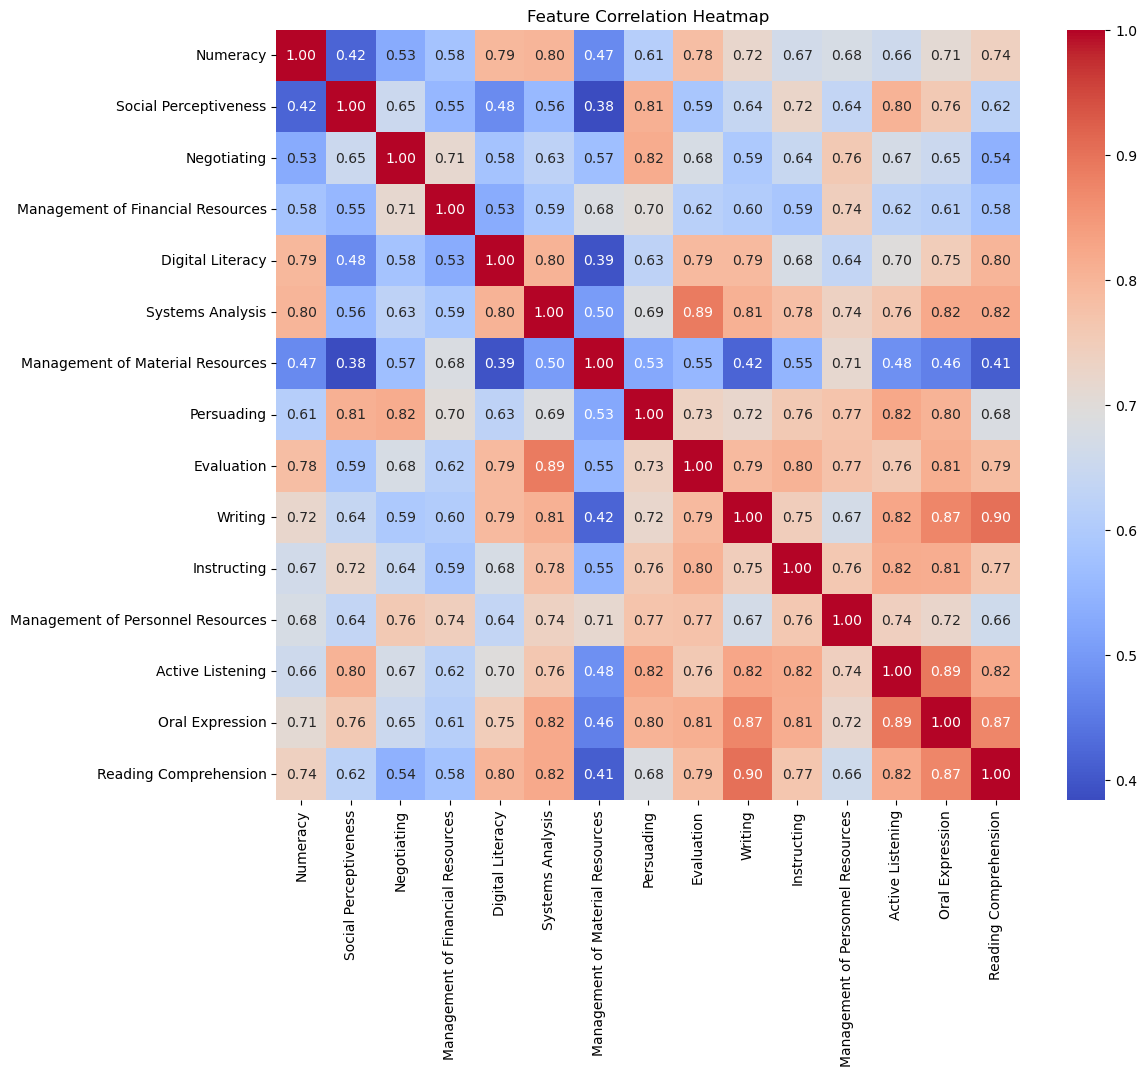

In [21]:
#Plotting Correlations
plt.figure(figsize=(12,10))

sns.heatmap(
    df_Correlation,
    annot=True,        
    cmap="coolwarm",   
    fmt=".2f"          
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#Skills that are highly correlated also seem to be core skills that everyone needs. 
#Therefore we will elimnate the more niche features like 'Management of Personelle Resources' and System Analysis.

In [23]:
Features_For_Correlation

['Numeracy',
 'Social Perceptiveness',
 'Negotiating',
 'Management of Financial Resources',
 'Digital Literacy',
 'Systems Analysis',
 'Management of Material Resources',
 'Persuading',
 'Evaluation',
 'Writing',
 'Instructing',
 'Management of Personnel Resources',
 'Active Listening',
 'Oral Expression',
 'Reading Comprehension']

In [ ]:
Final_Feature_Set = [
 'Numeracy',
 'Social Perceptiveness',
 'Negotiating',
 'Digital Literacy',
 'Persuading',
 'Evaluation',
 'Writing',
 'Instructing',
 'Active Listening',
 'Oral Expression',
 'Reading Comprehension']
#We have reduced the feature set down from 33 to 11, 
#which wil be more managable for simple similarity based models.

In [ ]:
#Saving Features
with open('Compentencies_Features.json', 'w') as File:
    json.dump(Final_Feature_Set, File, indent=2)

In [ ]:
#Saving Report
profile = ProfileReport(df_Data[Final_Feature_Set], title="Compentency Features EDA", explorative=True)
profile.to_file(f"Compentency_Features_EDA.html")

c:\Users\Tejas\anaconda3\envs\myRAG\Lib\site-packages\ydata_profiling\utils\dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 15.59it/s]
